# Dobór hiperparametrów Random Forest za pomocą Grid Search

Notebook służy do wyznaczenia najlepszych hiperparametrów modelu `RandomForestClassifier` dla zbioru `matches_features.csv`.
Wyszukiwanie odbywa się na tym samym zbiorze wejściowym, z którego korzysta pipeline `model_training`.

Jako metrykę optymalizacji przyjęto **ROC-AUC**, ponieważ dobrze ocenia zdolność modelu do rozróżniania klas na podstawie przewidywanych prawdopodobieństw i nie zależy od pojedynczego progu decyzyjnego.

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split


In [2]:
DATA_PATH = Path('../data/03_primary/matches_features.csv')
TARGET_COLUMN = 'player_A_won'
TEST_SIZE = 0.2
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

print(f'Kształt zbioru: {df.shape}')
print(f'Liczba cech wejściowych: {X.shape[1]}')
print(f'Udział klasy pozytywnej: {y.mean():.4f}')


Kształt zbioru: (40682, 34)
Liczba cech wejściowych: 33
Udział klasy pozytywnej: 0.5002


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')


X_train: (32545, 33)
X_test: (8137, 33)


## Siatka hiperparametrów

Zakres przeszukiwania został zdefiniowany wokół parametrów, które dawały sensowne wyniki bazowe.
Pozwala to uzasadnić wybór końcowej konfiguracji bez nadmiernego rozszerzania przestrzeni przeszukiwania.

In [4]:
def run_random_forest_grid_search(X_train, y_train, random_state=RANDOM_STATE):
    param_grid = {
        'n_estimators': [200, 300, 400],
        'max_depth': [10, 12, 14],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    rf = RandomForestClassifier(
        random_state=random_state,
        n_jobs=-1,
        max_features='sqrt',
    )

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        verbose=2,
        refit=True,
    )
    grid_search.fit(X_train, y_train)

    print('Najlepsze parametry:', grid_search.best_params_)
    print(f'Najlepszy wynik CV (ROC-AUC): {grid_search.best_score_:.4f}')

    cv_results = (
        pd.DataFrame(grid_search.cv_results_)
        .sort_values(by='mean_test_score', ascending=False)
        [[
            'mean_test_score',
            'std_test_score',
            'param_n_estimators',
            'param_max_depth',
            'param_min_samples_split',
            'param_min_samples_leaf',
        ]]
        .reset_index(drop=True)
    )

    return grid_search, cv_results


In [5]:
grid_search, cv_results = run_random_forest_grid_search(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_sa

In [ ]:
cv_results.head(10)


In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

pd.Series(test_metrics).round(4)


accuracy     0.6682
precision    0.6702
recall       0.6627
f1           0.6664
roc_auc      0.7286
dtype: float64

## Wynik uzyskany w przeprowadzonym eksperymencie

Dla wykonanej procedury `GridSearchCV` najlepszy zestaw parametrów był następujący:

- `n_estimators = 400`
- `max_depth = 12`
- `min_samples_split = 5`
- `min_samples_leaf = 2`
- `max_features = 'sqrt'`

Najlepszy wynik walidacji krzyżowej wyniósł `ROC-AUC = 0.7306`.
Na zbiorze testowym model uzyskał w przybliżeniu:

- `accuracy = 0.6682`
- `precision = 0.6702`
- `recall = 0.6627`
- `f1 = 0.6664`
- `roc_auc = 0.7286`


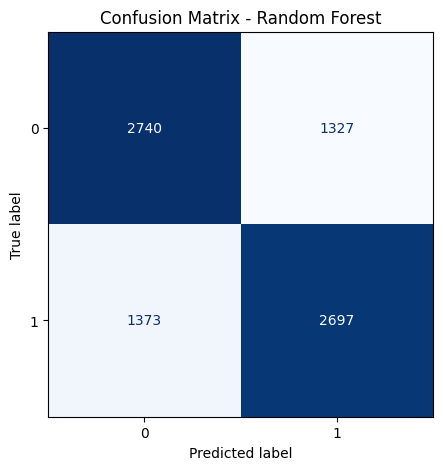

In [23]:
cm = confusion_matrix(y_test, y_pred)
cm

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Random Forest')
plt.show()


## Interpretacja macierzy pomyłek

Dla najlepszego modelu uzyskano następującą macierz pomyłek:

- true negatives (TN) = 2740
- false positives (FP) = 1327
- false negatives (FN) = 1373
- true positives (TP) = 2697

Oznacza to, że model poprawnie sklasyfikował 2740 przypadków porażki zawodnika A oraz 2697 przypadków jego zwycięstwa. Jednocześnie popełnił 1327 błędów typu false positive, czyli przewidział zwycięstwo zawodnika A mimo rzeczywistej porażki, oraz 1373 błędy typu false negative, czyli nie wykrył rzeczywistego zwycięstwa zawodnika A.

Macierz pomyłek potwierdza, że klasyfikator zachowuje się w sposób dość zrównoważony. Liczby błędów obu typów są do siebie zbliżone, co jest spójne z podobnymi wartościami precision i recall. Oznacza to, że model nie wykazuje silnej tendencji do faworyzowania jednej z klas, lecz w podobnym stopniu myli zwycięstwa i porażki zawodnika A. Z praktycznego punktu widzenia taki wynik można uznać za stabilny, choć nadal pozostaje przestrzeń do poprawy jakości modelu, zwłaszcza w zakresie ograniczenia liczby błędnych wskazań obu typów.
